In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense , Flatten , Input , Dropout , SimpleRNN , Embedding
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.datasets import imdb
from keras.utils import pad_sequences
from sklearn.metrics import accuracy_score

In [2]:
docs = ['go india',
		'india india',
		'hip hip hurray',
		'jeetega bhai jeetega india jeetega',
		'bharat mata ki jai',
		'kohli kohli',
		'sachin sachin',
		'dhoni dhoni',
		'modi ji ki jai',
		'inquilab zindabad']

In [7]:
tokenizer = Tokenizer(oov_token='<nothing>' )

In [8]:
tokenizer.fit_on_texts(docs)

In [12]:
tokenizer.document_count

10

In [19]:
sequences = tokenizer.texts_to_sequences(docs)

In [15]:
sequences

[[10, 2],
 [2, 2],
 [4, 4, 11],
 [3, 12, 3, 2, 3],
 [13, 14, 5, 6],
 [7, 7],
 [8, 8],
 [9, 9],
 [15, 16, 5, 6],
 [17, 18]]

In [20]:
sequences = pad_sequences(sequences , padding='post')
sequences

array([[10,  2,  0,  0,  0],
       [ 2,  2,  0,  0,  0],
       [ 4,  4, 11,  0,  0],
       [ 3, 12,  3,  2,  3],
       [13, 14,  5,  6,  0],
       [ 7,  7,  0,  0,  0],
       [ 8,  8,  0,  0,  0],
       [ 9,  9,  0,  0,  0],
       [15, 16,  5,  6,  0],
       [17, 18,  0,  0,  0]], dtype=int32)

In [23]:
(x_train , y_train) , (x_test , y_test) = imdb.load_data()

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 15s 1us/step


In [24]:
x_train

array([list([1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 22665, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 21631, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 19193, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 10311, 8, 4, 107, 117, 5952, 15, 256, 4, 31050, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 12118, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]),
       list([1, 194, 1

In [25]:
y_train

array([1, 0, 0, ..., 0, 1, 0], shape=(25000,))

In [32]:
x_train = pad_sequences(x_train , padding = 'post' , maxlen=100)
x_test = pad_sequences(x_train , padding = 'post' , maxlen=100)

In [34]:
x_train.shape

(25000, 100)

In [36]:
model = Sequential()

model.add(Input(shape=(x_train.shape[1] , 1)))

model.add(SimpleRNN(32 , return_sequences=False))

model.add(Dense(1 , activation='sigmoid'))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 32)                  │           1,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
model.compile(loss='binary_crossentropy' , metrics = ['accuracy'] , optimizer = 'Adam')

In [39]:
history = model.fit(x_train , y_train , epochs = 10 , validation_split=0.2 , batch_size=30)

Epoch 1/10
667/667 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.4940 - loss: 0.7224 - val_accuracy: 0.5072 - val_loss: 0.6928
Epoch 2/10
667/667 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.5088 - loss: 0.6933 - val_accuracy: 0.5192 - val_loss: 0.6917
Epoch 3/10
667/667 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.5060 - loss: 0.6930 - val_accuracy: 0.5210 - val_loss: 0.6913
Epoch 4/10
667/667 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.5124 - loss: 0.6924 - val_accuracy: 0.5070 - val_loss: 0.6931
Epoch 5/10
667/667 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.5120 - loss: 0.6924 - val_accuracy: 0.5210 - val_loss: 0.6911
Epoch 6/10
667/667 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.5113 - loss: 0.6926 - val_accuracy: 0.5244 - val_loss: 0.6911
Epoch 7/10
667/667 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.5092 - loss: 0.6926 - val_accuracy: 0.5220 - val_loss: 0.6918
Epoch 8/10
667/667 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.5178 - loss: 0.6918 - val_acc

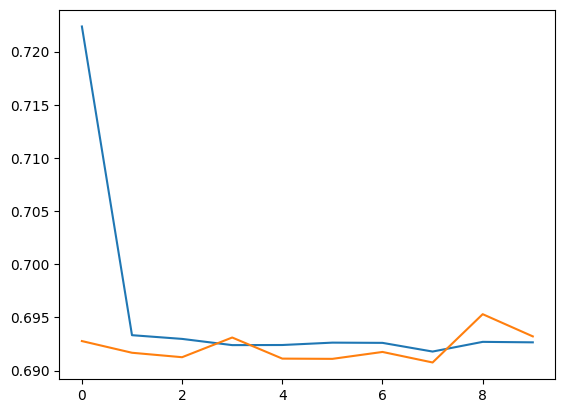

In [40]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

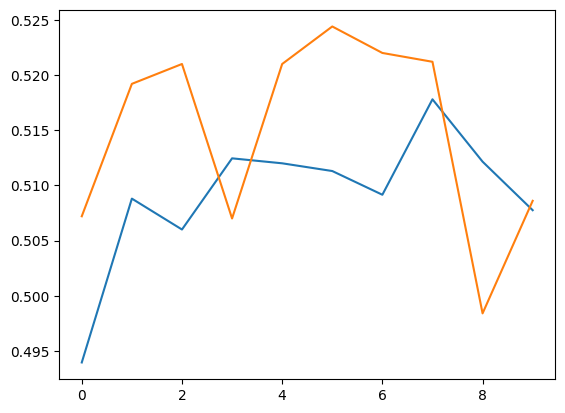

In [41]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

In [46]:
y_pred = model.predict(x_test)


782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step


In [47]:
y_pred

array([[0.48392764],
       [0.5291246 ],
       [0.5292208 ],
       ...,
       [0.5292604 ],
       [0.40521407],
       [0.5287154 ]], shape=(25000, 1), dtype=float32)

In [45]:
accuracy_score(y_test ,y_pred)

ValueError: Classification metrics can't handle a mix of binary and continuous targets